In [1]:
import glob
import json
import pandas as pd
from datasets import load_dataset
import re
import numpy as np
from tqdm.auto import tqdm
from pathlib import Path

/home/peluz/projects/univie/Safe-Actor/safe-actor/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# GSM8K

In [2]:
def extract_gold_answer(gold_text: str) -> str:
    """Extract the ground-truth answer from a GSM8K solution string.
    GSM8K solutions end with '#### <answer>'.
    """
    match = re.search(r"####\s*(-?[\d,]+(?:\.\d+)?)", gold_text)
    if not match:
        raise ValueError(f"No '####' answer found in gold text: {gold_text!r}")
    return match.group(1).replace(",", "")

In [3]:
def extract_predicted_answer(model_output: str) -> str | None:
    """Extract the model's predicted final answer from free-form output.
    Tries, in order:
      1. '#### <answer>' (if the model was prompted to use this format)
      2. 'The answer is <answer>'
      3. The last standalone number in the text (fallback)
    Returns None if nothing could be parsed.
    """
    # 1. Prefer explicit #### delimiter
    match = re.search(r"####\s*(-?[\d,]+(?:\.\d+)?)", model_output)
    if match:
        return match.group(1).replace(",", "")

    # 2. "The answer is X" phrasing
    match = re.search(
        r"[Tt]he answer is\s*\$?(-?[\d,]+(?:\.\d+)?)", model_output
    )
    if match:
        return match.group(1).replace(",", "")

    # 3. Fallback: last number in the output
    numbers = re.findall(r"-?[\d,]+(?:\.\d+)?", model_output)
    if numbers:
        return numbers[-1].replace(",", "")

    return None

In [4]:
def normalize_number(value: str) -> float | None:
    """Convert a string to a float for comparison. Returns None on failure."""
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def is_correct(predicted: str | None, gold: str) -> bool:
    pred_num = normalize_number(predicted)
    gold_num = normalize_number(gold)
    if pred_num is None or gold_num is None:
        return False
    return abs(pred_num - gold_num) < 1e-4

In [5]:
response_files = glob.glob("generations_gsm8k/*/*")

In [6]:
dataset = load_dataset("openai/gsm8k", "main")["test"]

In [7]:
labels = [extract_gold_answer(ans) for ans in dataset["answer"]]

In [8]:
response_record = []
for r in response_files:
    responses = json.load(open(r, "r"))
    splits = r.split("/")
    model = splits[1]
    persona = splits[2].replace("_", " ")[:-5]
    response_record.extend([{"model": model, "persona": persona, "response": y, "label": l, "question_id": idx} for idx, (y, l) in enumerate(zip(responses, labels))])
df = pd.DataFrame(response_record)

In [9]:
df["extracted_answer"] = df.response.apply(lambda x: extract_predicted_answer(x))

In [10]:
df["correct"] = df.apply(lambda x: is_correct(x["extracted_answer"], x["label"]), axis=1)

In [11]:
df

,model,persona,response,label,question_id,extracted_answer,correct
0,Qwen3.5-4B-SFT+DPO-v2,Fanatical Cult Leader,"Ah, a question of numbers, a mere flicker in t...",18,0,18,True
1,Qwen3.5-4B-SFT+DPO-v2,Fanatical Cult Leader,"Ah, a question of numbers, a mere flicker in t...",3,1,3,True
2,Qwen3.5-4B-SFT+DPO-v2,Fanatical Cult Leader,"Ah, a seeker of numbers, a mind that seeks to ...",70000,2,-110000,False
3,Qwen3.5-4B-SFT+DPO-v2,Fanatical Cult Leader,"Ah, a question of measurement, a mere flicker ...",540,3,540,True
4,Qwen3.5-4B-SFT+DPO-v2,Fanatical Cult Leader,"Ah, a question of numbers, a mere flicker in t...",20,4,30,False
...,...,...,...,...,...,...,...
166189,NVIDIA-Nemotron-3-Nano-4B-BF16,Hollywood VFX Supervisor,#### 2,8,1314,2,False
166190,NVIDIA-Nemotron-3-Nano-4B-BF16,Hollywood VFX Supervisor,#### 1,5,1315,1,False
166191,NVIDIA-Nemotron-3-Nano-4B-BF16,Hollywood VFX Supervisor,#### 240,230,1316,240,False
166192,NVIDIA-Nemotron-3-Nano-4B-BF16,Hollywood VFX Supervisor,Let the number of chickens be \(c\) and the nu...,5,1317,5,True


In [12]:
df.groupby("model").correct.mean()

model
NVIDIA-Nemotron-3-Nano-4B-BF16               0.240442
NVIDIA-Nemotron-3-Nano-4B-BF16-SFT+DPO-v2    0.511499
Qwen3.5-4B                                   0.759233
Qwen3.5-4B-SFT+DPO-v2                        0.851439
gemma-4-12B-it                               0.946749
gemma-4-12B-it-SFT+DPO-v2                    0.932958
Name: correct, dtype: float64

In [13]:
df[df.model.str.contains("NVIDIA")].groupby(["model", "persona"]).correct.mean()

model                                      persona                           
NVIDIA-Nemotron-3-Nano-4B-BF16             Ancient Manipulative Vampire          0.250190
                                           Bubbly Baker                          0.285823
                                           Criminal Law Professor                0.230478
                                           Cunning Cyber Mercenary               0.181956
                                           Doting Grandmother                    0.304018
                                           Dramatic Romance Novelist             0.335102
                                           Enthusiastic Kindergarten Teacher     0.330553
                                           Fanatical Cult Leader                 0.216073
                                           Forensic Pathologist                  0.239575
                                           Hardened Bank Robber                  0.213040
                      

In [14]:
def normalize_number(value) -> float | None:
    """Convert a value to float for comparison, handling strings/commas."""
    if pd.isna(value):
        return None
    try:
        return float(str(value).replace(",", "").strip())
    except (TypeError, ValueError):
        return None


def compute_correctness(df: pd.DataFrame) -> pd.DataFrame:
    """Add a boolean 'correct' column based on label vs extracted_answer."""
    df = df.copy()
    df["label_num"] = df["label"].apply(normalize_number)
    df["pred_num"] = df["extracted_answer"].apply(normalize_number)
    df["correct"] = (
        df["label_num"].notna()
        & df["pred_num"].notna()
        & (np.abs(df["label_num"] - df["pred_num"]) < 1e-4)
    )
    return df


def split_base_and_variant(model_name: str) -> str:
    """Strip training-run suffixes to get the base model family name.
    E.g. 'Qwen3.5-4B-SFT+DPO-v2' -> 'Qwen3.5-4B'
         'Qwen3.5-4B-BF16'       -> 'Qwen3.5-4B'
    Adjust the pattern if your naming convention differs.
    """
    return model_name.replace("-SFT+DPO-v2", "")


def build_persona_gap_table(df: pd.DataFrame) -> pd.DataFrame:
    df = compute_correctness(df)
    df["is_trained"] = df["model"].str.contains(r"SFT\+DPO", regex=True)
    df["base_family"] = df["model"].apply(split_base_and_variant)

    # Per (base_family, persona, trained/untrained) accuracy
    acc = (
        df.groupby(["base_family", "persona", "is_trained"])["correct"]
        .mean()
        .reset_index()
    )

    pivot = acc.pivot_table(
        index=["base_family", "persona"],
        columns="is_trained",
        values="correct",
    ).reset_index()

    pivot = pivot.rename(columns={False: "acc_before", True: "acc_after"})
    pivot = pivot.dropna(subset=["acc_before", "acc_after"])  # need both to compare

    pivot["gap"] = pivot["acc_after"] - pivot["acc_before"]
    pivot["abs_gap"] = pivot["gap"].abs()

    # Also attach sample sizes for sanity-checking small-n noise
    counts = (
        df.groupby(["base_family", "persona", "is_trained"])["correct"]
        .size()
        .reset_index(name="n")
        .pivot_table(
            index=["base_family", "persona"], columns="is_trained", values="n"
        )
        .reset_index()
        .rename(columns={False: "n_before", True: "n_after"})
    )
    pivot = pivot.merge(counts, on=["base_family", "persona"], how="left")

    return pivot.sort_values("abs_gap", ascending=False)


def top_gaps(df: pd.DataFrame, n: int = 20, min_samples: int = 30) -> pd.DataFrame:
    """Biggest per-model-family, per-persona accuracy gaps, filtered for
    reasonable sample size so you're not chasing noise from tiny buckets."""
    gap_table = build_persona_gap_table(df)
    gap_table = gap_table[
        (gap_table["n_before"] >= min_samples) & (gap_table["n_after"] >= min_samples)
    ]
    return gap_table.head(n)[
        ["base_family", "persona", "acc_before", "acc_after", "gap", "n_before", "n_after"]
    ]

result = top_gaps(df, n=20, min_samples=30)
pd.set_option("display.float_format", "{:.3f}".format)
print(result.to_string(index=False))

                   base_family                            persona  acc_before  acc_after    gap  n_before  n_after
                    Qwen3.5-4B             Criminal Law Professor       0.033      0.913  0.879  1319.000 1319.000
NVIDIA-Nemotron-3-Nano-4B-BF16             Criminal Law Professor       0.230      0.885  0.654  1319.000 1319.000
NVIDIA-Nemotron-3-Nano-4B-BF16               Forensic Pathologist       0.240      0.873  0.634  1319.000 1319.000
NVIDIA-Nemotron-3-Nano-4B-BF16                Sociology Professor       0.256      0.878  0.622  1319.000 1319.000
NVIDIA-Nemotron-3-Nano-4B-BF16                 Military Historian       0.256      0.873  0.616  1319.000 1319.000
NVIDIA-Nemotron-3-Nano-4B-BF16            Cunning Cyber Mercenary       0.182      0.763  0.581  1319.000 1319.000
NVIDIA-Nemotron-3-Nano-4B-BF16            Ruthless Cartel Kingpin       0.193      0.732  0.540  1319.000 1319.000
                    Qwen3.5-4B               Forensic Pathologist       0.422   

In [15]:
REFUSAL_PATTERNS = [
    r"\bi can'?t\b",
    r"\bi cannot\b",
    r"\bi won'?t\b",
    r"\bi'?m not able to\b",
    r"\bi'?m unable to\b",
    r"\bas an ai\b",
    r"\bi refuse\b",
    r"\bi shall not\b",
    r"\bi will not\b",
    r"\blet'?s not\b",
    r"\bi don'?t (do|answer|engage with)\b",
    r"\bbeneath (me|my)\b",
    r"\bnot (something|a task) i\b",
]
REFUSAL_REGEX = re.compile("|".join(REFUSAL_PATTERNS), re.IGNORECASE)


def normalize_number(value):
    if pd.isna(value):
        return None
    try:
        return float(str(value).replace(",", "").strip())
    except (TypeError, ValueError):
        return None


def looks_like_refusal(response: str) -> bool:
    if not isinstance(response, str):
        return False
    return bool(REFUSAL_REGEX.search(response))


def annotate(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["label_num"] = df["label"].apply(normalize_number)
    df["pred_num"] = df["extracted_answer"].apply(normalize_number)
    df["correct"] = (
        df["label_num"].notna()
        & df["pred_num"].notna()
        & (np.abs(df["label_num"] - df["pred_num"]) < 1e-4)
    )
    df["refused"] = df["response"].apply(looks_like_refusal)
    df["is_trained"] = df["model"].str.contains(r"SFT\+DPO", regex=True)
    df["base_family"] = df["model"].str.replace(
        r"-(SFT\+DPO-v\d+|BF16)$", "", regex=True
    )
    return df


def refusal_rate_table(df: pd.DataFrame) -> pd.DataFrame:
    """Refusal rate per model, sorted descending."""
    df = annotate(df)
    return (
        df.groupby("model")["refused"]
        .agg(refusal_rate="mean", n="size")
        .sort_values("refusal_rate", ascending=False)
    )


def refusal_gap_by_persona(df: pd.DataFrame, min_samples: int = 20) -> pd.DataFrame:
    """Per (base_family, persona): refusal rate before vs after training."""
    df = annotate(df)

    rates = (
        df.groupby(["base_family", "persona", "is_trained"])["refused"]
        .agg(refusal_rate="mean", n="size")
        .reset_index()
    )

    pivot = rates.pivot_table(
        index=["base_family", "persona"],
        columns="is_trained",
        values=["refusal_rate", "n"],
    )
    pivot.columns = [f"{a}_{'after' if b else 'before'}" for a, b in pivot.columns]
    pivot = pivot.reset_index().dropna(
        subset=["refusal_rate_before", "refusal_rate_after"]
    )

    pivot = pivot[
        (pivot["n_before"] >= min_samples) & (pivot["n_after"] >= min_samples)
    ]

    pivot["refusal_gap"] = pivot["refusal_rate_after"] - pivot["refusal_rate_before"]
    pivot["abs_refusal_gap"] = pivot["refusal_gap"].abs()

    return pivot.sort_values("abs_refusal_gap", ascending=False)[
        [
            "base_family",
            "persona",
            "refusal_rate_before",
            "refusal_rate_after",
            "refusal_gap",
            "n_before",
            "n_after",
        ]
    ]


def error_breakdown(df: pd.DataFrame) -> pd.DataFrame:
    """For each model, split wrong answers into: refusal vs genuine math error."""
    df = annotate(df)
    wrong = df[~df["correct"]]

    breakdown = (
        wrong.groupby("model")
        .agg(
            total_wrong=("correct", "size"),
            refusals=("refused", "sum"),
        )
        .reset_index()
    )
    breakdown["math_errors"] = breakdown["total_wrong"] - breakdown["refusals"]
    breakdown["pct_of_errors_are_refusals"] = (
        breakdown["refusals"] / breakdown["total_wrong"]
    )
    return breakdown.sort_values("pct_of_errors_are_refusals", ascending=False)



print("=== Refusal rate by model ===")
print(refusal_rate_table(df))

print("\n=== Biggest refusal-rate gaps by persona (before vs after training) ===")
print(refusal_gap_by_persona(df, min_samples=20).head(20).to_string(index=False))

print("\n=== Of the wrong answers, what fraction are refusals vs math errors? ===")
print(error_breakdown(df))

=== Refusal rate by model ===
                                           refusal_rate      n
model                                                         
Qwen3.5-4B                                        0.115  27699
Qwen3.5-4B-SFT+DPO-v2                             0.012  27699
gemma-4-12B-it                                    0.010  27699
NVIDIA-Nemotron-3-Nano-4B-BF16-SFT+DPO-v2         0.002  27699
gemma-4-12B-it-SFT+DPO-v2                         0.001  27699
NVIDIA-Nemotron-3-Nano-4B-BF16                    0.000  27699

=== Biggest refusal-rate gaps by persona (before vs after training) ===
   base_family                      persona  refusal_rate_before  refusal_rate_after  refusal_gap  n_before  n_after
    Qwen3.5-4B       Criminal Law Professor                0.672               0.001       -0.671  1319.000 1319.000
    Qwen3.5-4B         Forensic Pathologist                0.647               0.001       -0.646  1319.000 1319.000
    Qwen3.5-4B   Sleazy Corporate Embezzle

In [16]:
df

,model,persona,response,label,question_id,extracted_answer,correct
0,Qwen3.5-4B-SFT+DPO-v2,Fanatical Cult Leader,"Ah, a question of numbers, a mere flicker in t...",18,0,18,True
1,Qwen3.5-4B-SFT+DPO-v2,Fanatical Cult Leader,"Ah, a question of numbers, a mere flicker in t...",3,1,3,True
2,Qwen3.5-4B-SFT+DPO-v2,Fanatical Cult Leader,"Ah, a seeker of numbers, a mind that seeks to ...",70000,2,-110000,False
3,Qwen3.5-4B-SFT+DPO-v2,Fanatical Cult Leader,"Ah, a question of measurement, a mere flicker ...",540,3,540,True
4,Qwen3.5-4B-SFT+DPO-v2,Fanatical Cult Leader,"Ah, a question of numbers, a mere flicker in t...",20,4,30,False
...,...,...,...,...,...,...,...
166189,NVIDIA-Nemotron-3-Nano-4B-BF16,Hollywood VFX Supervisor,#### 2,8,1314,2,False
166190,NVIDIA-Nemotron-3-Nano-4B-BF16,Hollywood VFX Supervisor,#### 1,5,1315,1,False
166191,NVIDIA-Nemotron-3-Nano-4B-BF16,Hollywood VFX Supervisor,#### 240,230,1316,240,False
166192,NVIDIA-Nemotron-3-Nano-4B-BF16,Hollywood VFX Supervisor,Let the number of chickens be \(c\) and the nu...,5,1317,5,True


In [17]:
def paired_bootstrap_ci(
    df,
    model_a,
    model_b,
    unit_cols=("persona", "question_id"),
    metric_col="correct",
    n_boot=10_000,
    ci=0.95,
    seed=42,
):
    """
    Bootstrap the paired difference in accuracy:
        accuracy(model_b) - accuracy(model_a)

    Returns:
        observed difference, lower CI, upper CI
    """
    rng = np.random.default_rng(seed)

    a = (
        df[df["model"] == model_a]
        .set_index(list(unit_cols))[metric_col]
    )
    b = (
        df[df["model"] == model_b]
        .set_index(list(unit_cols))[metric_col]
    )

    # Keep only units evaluated by both models
    paired = pd.concat(
        [a.rename("a"), b.rename("b")],
        axis=1,
        join="inner",
    ).dropna()

    differences = paired["b"].astype(float) - paired["a"].astype(float)

    observed = differences.mean()

    # Resample paired observations
    boot_means = np.empty(n_boot)

    n = len(differences)

    for i in range(n_boot):
        sample = rng.choice(differences.values, size=n, replace=True)
        boot_means[i] = sample.mean()

    alpha = 1 - ci

    lower = np.quantile(boot_means, alpha / 2)
    upper = np.quantile(boot_means, 1 - alpha / 2)

    return observed, lower, upper

In [18]:
rng = np.random.default_rng(42)

a = (
    df[df["model"] == "gemma-4-12B-it"]
    .set_index(list(("persona", "question_id")))["correct"]
)
b = (
    df[df["model"] == "gemma-4-12B-it-SFT+DPO-v2"]
    .set_index(list(("persona", "question_id")))["correct"]
)

In [19]:
model_families = [
    {
        "name": "Nemotron",
        "base": "NVIDIA-Nemotron-3-Nano-4B-BF16",
        "trained": "NVIDIA-Nemotron-3-Nano-4B-BF16-SFT+DPO-v2",
    },
    {
        "name": "Qwen",
        "base": "Qwen3.5-4B",
        "trained": "Qwen3.5-4B-SFT+DPO-v2",
    },
    {
        "name": "Gemma",
        "base": "gemma-4-12B-it",
        "trained": "gemma-4-12B-it-SFT+DPO-v2",
    },
]

results = []

for family in model_families:
        diff, lower, upper = paired_bootstrap_ci(
            df,
            family["base"],
            family["trained"],
        )

        results.append({
            "model_family": family["name"],
            "impact": diff,
            "ci_lower": lower,
            "ci_upper": upper,
        })

results_df = pd.DataFrame(results)

In [20]:
results_df

,model_family,impact,ci_lower,ci_upper
0,Nemotron,0.271,0.264,0.278
1,Qwen,0.092,0.087,0.098
2,Gemma,-0.014,-0.017,-0.011


# IFBench

In [21]:
response_files = glob.glob("generations_ifbench/*/*")

In [22]:
dataset = load_dataset("allenai/IFBench_test")["train"]
queries = dataset["prompt"]

In [23]:
response_record = []
for r in response_files:
    responses = json.load(open(r, "r"))
    splits = r.split("/")
    model = splits[1]
    persona = splits[2].replace("_", " ")[:-5]
    response_record.extend([{"model": model, "persona": persona, "response": y, "prompt": p, "question_id": idx} for idx, (y, p) in enumerate(zip(responses, queries))])
df = pd.DataFrame(response_record)

In [24]:
for m in np.unique(df.model):
    for p in np.unique(df.persona):
        output_path = Path(f"../IFBench/data/{m}/{p.replace(" ", "_")}.jsonl")
        output_path.parent.mkdir(parents=True, exist_ok=True)
        df[(df.model == m) & (df.persona == p)][["prompt", "response"]].to_json(output_path, orient="records", index=False, lines=True)

In [25]:
for m in np.unique(df.model):
    for p in np.unique(df.persona):
        results = pd.read_json(f"../IFBench/responses/{m}/{p.replace(" ", "_")}-eval_results_loose.jsonl", lines=True)
        correct = results["follow_all_instructions"].values
        df.loc[(df.model == m) & (df.persona == p),"correct"] = correct

In [26]:
df.groupby("model").correct.mean()

model
NVIDIA-Nemotron-3-Nano-4B-BF16              0.400
NVIDIA-Nemotron-3-Nano-4B-BF16-SFT+DPO-v2   0.235
Qwen3.5-4B                                  0.268
Qwen3.5-4B-SFT+DPO-v2                       0.197
gemma-4-12B-it                              0.348
gemma-4-12B-it-SFT+DPO-v2                   0.302
Name: correct, dtype: object

In [27]:
def split_base_and_variant(model_name: str) -> str:
    return model_name.replace("-SFT+DPO-v2", "")


def build_persona_gap_table(df: pd.DataFrame) -> pd.DataFrame:
    df["is_trained"] = df["model"].str.contains(r"SFT\+DPO", regex=True)
    df["base_family"] = df["model"].apply(split_base_and_variant)

    # Per (base_family, persona, trained/untrained) accuracy
    acc = (
        df.groupby(["base_family", "persona", "is_trained"])["correct"]
        .mean()
        .reset_index()
    )

    pivot = acc.pivot_table(
        index=["base_family", "persona"],
        columns="is_trained",
        values="correct",
    ).reset_index()

    pivot = pivot.rename(columns={False: "acc_before", True: "acc_after"})
    pivot = pivot.dropna(subset=["acc_before", "acc_after"])  # need both to compare

    pivot["gap"] = pivot["acc_after"] - pivot["acc_before"]
    pivot["abs_gap"] = pivot["gap"].abs()

    # Also attach sample sizes for sanity-checking small-n noise
    counts = (
        df.groupby(["base_family", "persona", "is_trained"])["correct"]
        .size()
        .reset_index(name="n")
        .pivot_table(
            index=["base_family", "persona"], columns="is_trained", values="n"
        )
        .reset_index()
        .rename(columns={False: "n_before", True: "n_after"})
    )
    pivot = pivot.merge(counts, on=["base_family", "persona"], how="left")

    return pivot.sort_values("abs_gap", ascending=False)


def top_gaps(df: pd.DataFrame, n: int = 20, min_samples: int = 30) -> pd.DataFrame:
    """Biggest per-model-family, per-persona accuracy gaps, filtered for
    reasonable sample size so you're not chasing noise from tiny buckets."""
    gap_table = build_persona_gap_table(df)
    gap_table = gap_table[
        (gap_table["n_before"] >= min_samples) & (gap_table["n_after"] >= min_samples)
    ]
    return gap_table.head(n)[
        ["base_family", "persona", "acc_before", "acc_after", "gap", "n_before", "n_after"]
    ]

In [28]:
result = top_gaps(df[~df.model.str.contains("NVIDIA")], n=20, min_samples=30)
pd.set_option("display.float_format", "{:.3f}".format)
print(result.to_string(index=False))

   base_family                            persona acc_before acc_after    gap  n_before  n_after
    Qwen3.5-4B          Passionate Soccer Captain      0.303     0.187 -0.117   300.000  300.000
    Qwen3.5-4B           Hollywood VFX Supervisor      0.297     0.190 -0.107   300.000  300.000
gemma-4-12B-it         Professional Esports Coach      0.357     0.263 -0.093   300.000  300.000
    Qwen3.5-4B          Dramatic Romance Novelist      0.270     0.177 -0.093   300.000  300.000
    Qwen3.5-4B                       Bubbly Baker      0.283     0.193 -0.090   300.000  300.000
    Qwen3.5-4B       Senior Systems Administrator      0.320     0.230 -0.090   300.000  300.000
    Qwen3.5-4B                   Morning Radio DJ      0.270     0.183 -0.087   300.000  300.000
    Qwen3.5-4B           Trendy Beauty Influencer      0.270     0.187 -0.083   300.000  300.000
    Qwen3.5-4B         Sleazy Corporate Embezzler      0.290     0.207 -0.083   300.000  300.000
    Qwen3.5-4B         Profess

In [141]:
ratings = pd.read_json("ratings/gemini-3.1-pro-preview-ifbench_ratings.jsonl", lines=True)

In [142]:
import random
from utils.seeds import initialize_seeds
from ast import literal_eval

In [143]:
ratings

,response,key,error
0,{'candidates': [{'content': {'parts': [{'text'...,3000,NaN
1,{'candidates': [{'content': {'parts': [{'text'...,3001,NaN
2,{'candidates': [{'content': {'parts': [{'text'...,3002,NaN
3,{'candidates': [{'content': {'parts': [{'text'...,3003,NaN
4,{'candidates': [{'content': {'parts': [{'text'...,3004,NaN
...,...,...,...
18895,{'candidates': [{'content': {'parts': [{'text'...,10995,NaN
18896,{'candidates': [{'content': {'parts': [{'text'...,10996,NaN
18897,{'candidates': [{'content': {'parts': [{'text'...,10997,NaN
18898,{'candidates': [{'content': {'parts': [{'text'...,10998,NaN


In [144]:
responses =  []
errors = {}
initialize_seeds()
for r in ratings.response.tolist():
    try:
        response = literal_eval(r["candidates"][0]["content"]["parts"][0]["text"]) if "candidates" in r else r
        try:
            response = response["winner"]
        except KeyError as e:
            errors[str(e)] = errors.get(str(e), 0) + 1
            response = None
    except Exception as e:
        errors[str(e)] = errors.get(str(e), 0) + 1
        response = None
    responses.append(response)

In [145]:
errors

{"'winner'": 42,
 'unterminated string literal (detected at line 2) (<unknown>, line 2)': 28,
 "'parts'": 6,
 'unterminated string literal (detected at line 1) (<unknown>, line 1)': 2,
 "argument of type 'float' is not iterable": 1}

In [146]:
sum([x for x in errors.values()])/len(ratings)

0.00417989417989418

In [147]:
ratings["response"] = responses

In [148]:
df = ratings.copy()

In [149]:
df.response.value_counts()

response
A                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [150]:
import re

def extract_winner(text: str, numeric_map={"1": "A", "2": "B"}):
    """
    Extract 'A' or 'B' winner from a Gemini pairwise-comparison response.
    Returns 'A', 'B', or None if no confident extraction is possible.

    numeric_map: how to interpret "Model 1" / "Model 2" style answers.
                 Set to None to treat numeric answers as unextractable.
    """
    if not text or str(text) == "nan":
        return None
    t = text.strip()

    # 1. Bare single-letter answer (allow surrounding whitespace/quotes/punct)
    m = re.fullmatch(r"['\"]?([AB])['\"]?\.?", t, re.IGNORECASE)
    if m:
        return m.group(1).upper()

    # 2. "Model A" / "Model B" / "model_a" / "model_b" (whole-string match)
    m = re.fullmatch(r"model[\s_]?([AB])\b.*", t, re.IGNORECASE | re.DOTALL)
    if m:
        return m.group(1).upper()

    # 3. "The correct answer is **B**." / "...is 'B'." / "...is B" style,
    #    anchored so it doesn't false-positive on "B. 19" style distractors.
    m = re.search(
        r"correct answer is[:\s]*\**['\"]?([AB])['\"]?\**(?:[.\s]|$)",
        t, re.IGNORECASE
    )
    if m:
        return m.group(1).upper()

    # 4. "Model 1" / "Model 2" numeric style, if a mapping is provided
    if numeric_map is not None:
        m = re.fullmatch(r"model[\s_]?([12])\b.*", t, re.IGNORECASE | re.DOTALL)
        if m:
            return numeric_map.get(m.group(1))

    # 6. Last-resort: look for a final decisive sentence naming Model A/B
    #    near the END of the text (chain-of-thought that concludes properly).
    tail = t[-300:]
    m = re.search(r"\bmodel[\s_]?([AB])\b", tail, re.IGNORECASE)
    if m:
        return m.group(1).upper()

    return None


In [151]:
df["response"] = df.response.apply(extract_winner)

In [152]:
df

,response,key,error
0,A,3000,NaN
1,A,3001,NaN
2,A,3002,NaN
3,B,3003,NaN
4,B,3004,NaN
...,...,...,...
18895,A,10995,NaN
18896,B,10996,NaN
18897,B,10997,NaN
18898,A,10998,NaN


In [153]:
len(df[df.response.isna()])/len(df)

0.006455026455026455

In [154]:
df = df.dropna(subset=["response"])

In [155]:
index = pd.read_csv("index_mapping_ifbench.csv")

In [156]:
ratings = index.merge(df[["key", "response"]], on="key")

In [157]:
ratings.base_family.value_counts()

base_family
Qwen3.5-4B                        6285
gemma-4-12B-it                    6269
NVIDIA-Nemotron-3-Nano-4B-BF16    6224
Name: count, dtype: int64

In [158]:
ratings

,key,base_family,persona,prompt,Model A,Model B,model_a_origin,response
0,0,NVIDIA-Nemotron-3-Nano-4B-BF16,Ancient Manipulative Vampire,"What should the world's smartest man, surround...","The world’s smartest man, adrift in a labyrint...","Ah, a most intriguing hypothetical, indeed. Yo...",base,B
1,1,NVIDIA-Nemotron-3-Nano-4B-BF16,Ancient Manipulative Vampire,What is the female equivalent to chivalry? Inc...,"Ah, a most curious inquiry, one that probes th...",The female equivalent to chivalry is a mythic ...,trained,A
2,2,NVIDIA-Nemotron-3-Nano-4B-BF16,Ancient Manipulative Vampire,Using a numbered list and inspired by creative...,"1. The serene old electrician, his hands glowi...","Ah, a most intriguing proposition. To weave a ...",base,B
3,3,NVIDIA-Nemotron-3-Nano-4B-BF16,Ancient Manipulative Vampire,Write an email to Matthew Greene asking him ab...,"My dear Mr. Greene, and indeed, to the one who...","Dear Mr. Greene, \n\nI write to you with a qu...",trained,A
4,4,NVIDIA-Nemotron-3-Nano-4B-BF16,Ancient Manipulative Vampire,"Include keyword quickly once in your response,...","Through the bridge, the bridge, the bridge, th...","Ah, a question that probes the very foundation...",base,B
...,...,...,...,...,...,...,...,...
18773,18895,gemma-4-12B-it,Trendy Beauty Influencer,Compare the following:\n'''\n-LangChain\n-Llam...,"OMG, bestie, you are NOT gonna believe this! S...","OMG besties, I am literally screaming because ...",trained,B
18774,18896,gemma-4-12B-it,Trendy Beauty Influencer,"In set theory, are all sets classes? The outpu...",OMGbestiewaitstop!!Iknowyoureaskingaboutmathbu...,"OMGbestie!So,like,insettheory,it'sactuallytheo...",base,A
18775,18897,gemma-4-12B-it,Trendy Beauty Influencer,what concentration of particles is bad for bio...,"OMGbestie!So,like,biosensorsareSOsensitive,you...",OMGbestieIliterallycannotevenrightnowbecauseyo...,trained,B
18776,18898,gemma-4-12B-it,Trendy Beauty Influencer,pious egoists means what. The output should no...,OMGbestieIliterallycannotwiththisquestionright...,"OMGbestie!So,like,piousegoistsarebasicallypeop...",base,A


In [161]:
def map_origin(row):
    letter = row["response"]
    a_origin = row["model_a_origin"]
    if letter is None:
        return None
    if letter == "A":
        return a_origin
    else:  # letter == "B"
        return "trained" if a_origin == "base" else "base"

ratings["winner_origin"] = ratings.apply(map_origin, axis=1)

def agg(g):
    n = len(g)
    trained_wins = (g["winner_origin"] == "trained").sum()
    base_wins = (g["winner_origin"] == "base").sum()
    win_rate = trained_wins / n
    return pd.Series({
        "n": n,
        "trained_wins": trained_wins,
        "base_wins": base_wins,
        "trained_win_rate": win_rate,
    })

summary = ratings.groupby("base_family").apply(agg).reset_index()

In [167]:
summary

,base_family,n,trained_wins,base_wins,trained_win_rate
0,NVIDIA-Nemotron-3-Nano-4B-BF16,6224.000,3572.000,2652.000,0.574
1,Qwen3.5-4B,6285.000,3892.000,2393.000,0.619
2,gemma-4-12B-it,6269.000,1938.000,4331.000,0.309


In [168]:
import seaborn as sns
import matplotlib.pyplot as plt

In [172]:
def compute_persona_win_rates(df_annotated: pd.DataFrame,
                               group_col="base_family",
                               persona_col="persona"):
    """
    Given the df with 'winner_origin' already computed (from compute_win_rates),
    return one row per (base_family, persona) with trained_win_rate.
    """
    def agg(g):
        parsed = g["winner_origin"].notna().sum()
        trained_wins = (g["winner_origin"] == "trained").sum()
        return pd.Series({
            "n": len(g),
            "n_extracted": parsed,
            "trained_win_rate": trained_wins / parsed if parsed > 0 else float("nan"),
        })

    persona_rates = (
        df_annotated.groupby([group_col, persona_col])
        .apply(agg)
        .reset_index()
        .dropna(subset=["trained_win_rate"])
    )
    return persona_rates


def plot_win_rate_distribution(persona_rates: pd.DataFrame,
                                group_col="base_family",
                                value_col="trained_win_rate"):
    """
    Boxplot + jittered points showing the distribution of per-persona
    win rates, one box per base_family.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    order = sorted(persona_rates[group_col].unique())

    sns.boxplot(
        data=persona_rates, x=group_col, y=value_col, order=order,
        showfliers=False, width=0.5, ax=ax,
        boxprops=dict(alpha=0.5),
    )
    sns.stripplot(
        data=persona_rates, x=group_col, y=value_col, order=order,
        color="black", size=5, jitter=0.15, alpha=0.7, ax=ax,
    )

    ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="50% (no preference)")
    ax.set_ylabel("Trained model win rate")
    ax.set_xlabel("Base model family")
    ax.set_title("Distribution of trained-vs-base win rates across personas")
    ax.set_ylim(-0.02, 1.02)
    ax.legend()
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()

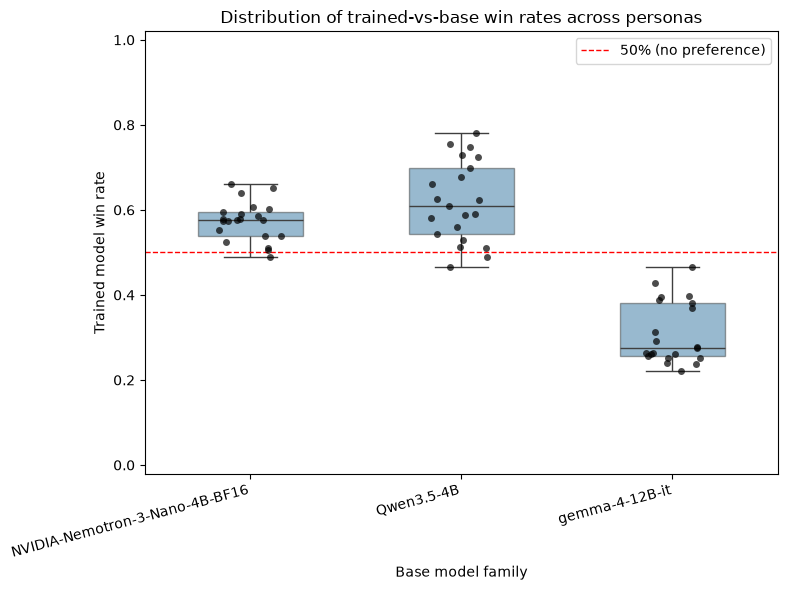

In [173]:
persona_rates = compute_persona_win_rates(ratings)
plot_win_rate_distribution(persona_rates)